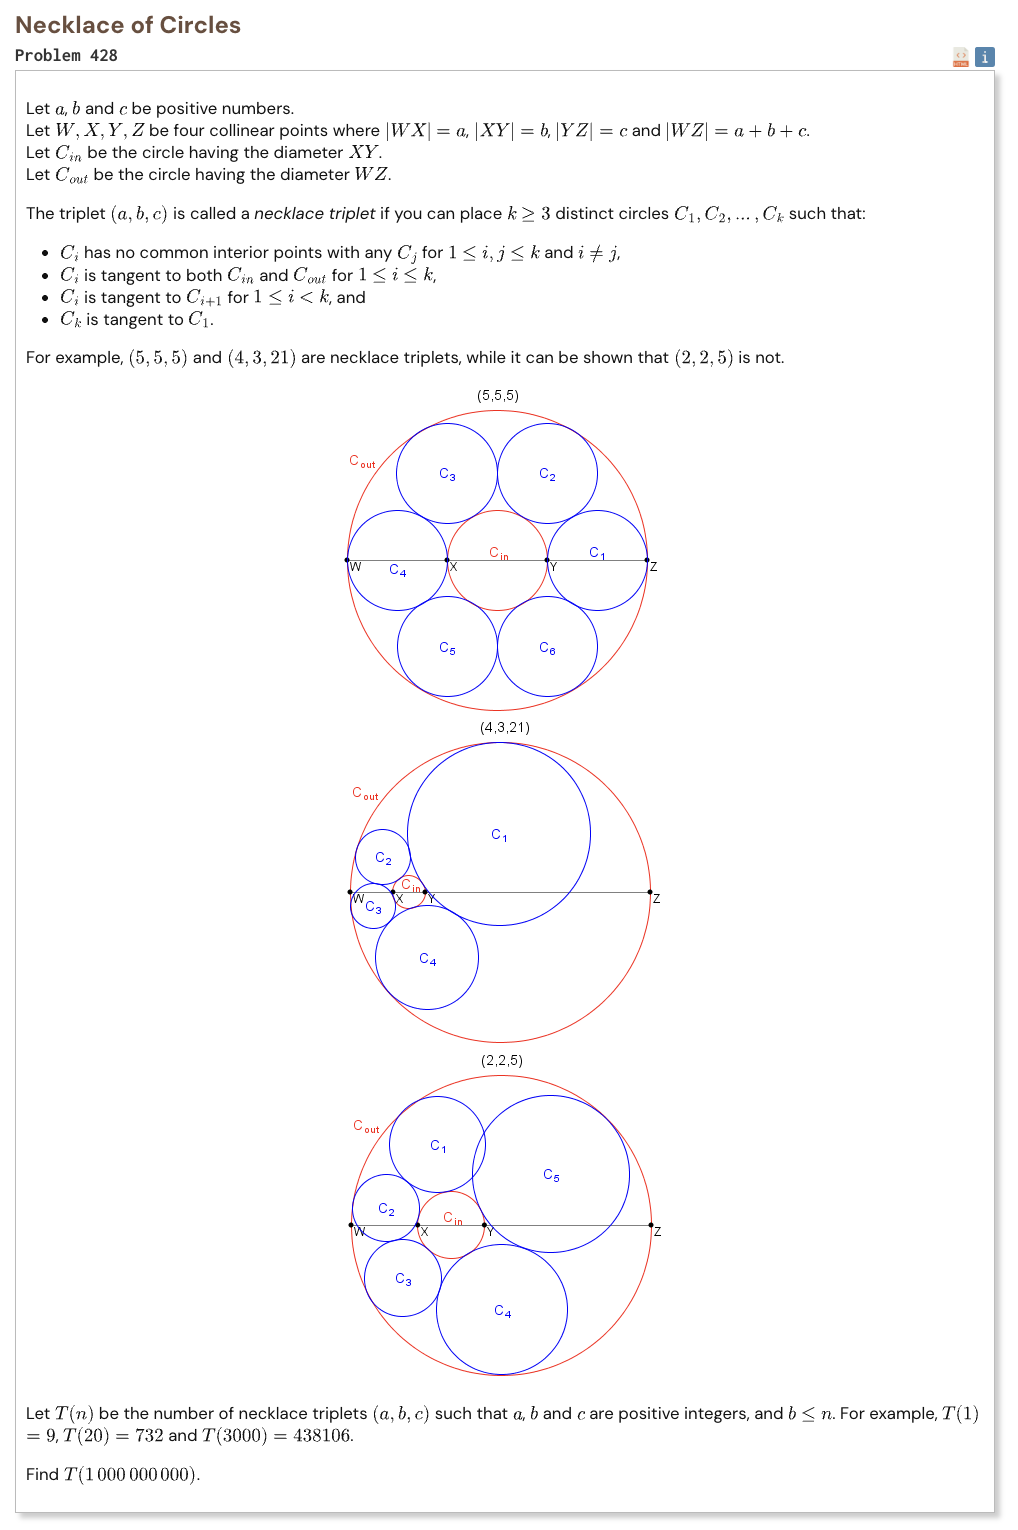

## Initial approach

-   use the Steiner chain condition to replace the circle geometry with a number theory condition
-   only three chain types are possible, corresponding to three special angle values
-   for each value of b, each chain type becomes a divisor counting problem
-   the first two types are counted using the divisors of 2 times b squared and 12 times b squared
-   the last type uses divisors of 4 times b squared with an extra remainder condition modulo 3
-   factor each b to calculate these divisor counts without constructing any circles
-   sum the counts for every b and use the given small values to check the logic

```python

import math

def factorize(n):
    factors = {}
    p = 2

    while p * p <= n:
        while n % p == 0:
            factors[p] = factors.get(p, 0) + 1
            n //= p
        p += 1

    if n > 1:
        factors[n] = factors.get(n, 0) + 1

    return factors


def divisor_count_from_factors(factors):
    total = 1

    for exponent in factors.values():
        total *= exponent + 1

    return total


def multiplied_square_factors(b, multiplier):
    factors = {}

    for p, e in factorize(b).items():
        factors[p] = 2 * e

    for p, e in factorize(multiplier).items():
        factors[p] = factors.get(p, 0) + e

    return factors


def divisors_from_factors(factors):
    divisors = [1]

    for p, e in factors.items():
        new_divisors = []

        power = 1

        for _ in range(e + 1):
            for d in divisors:
                new_divisors.append(d * power)

            power *= p

        divisors = new_divisors

    return divisors


def count_for_b(b):
    first = divisor_count_from_factors(
        multiplied_square_factors(b, 2)
    )

    second = divisor_count_from_factors(
        multiplied_square_factors(b, 12)
    )

    factors = multiplied_square_factors(b, 4)
    third = 0
    target = (-b) % 3
    value = 4 * b * b

    for x in divisors_from_factors(factors):
        y = value // x

        if x % 3 == target and y % 3 == target:
            third += 1

    return first + second + third


def T(n):
    total = 0

    for b in range(1, n + 1):
        total += count_for_b(b)

    return total


print(T(1))
print(T(20))
print(T(3000))

print("Result:", result)

```

this takes too long to run, needs an optimization